Loading data...
✅ Apple data using price column: Close
✅ Microsoft data using price column: Close

--- Apple Data Preview ---
         Date     Close      High       Low      Open     Volume
0  1980-12-12  0.098485  0.098913  0.098485  0.098485  469033600
1  1980-12-15  0.093347  0.093775  0.093347  0.093775  175884800
2  1980-12-16  0.086495  0.086924  0.086495  0.086924  105728000
3  1980-12-17  0.088636  0.089064  0.088636  0.088636   86441600
4  1980-12-18  0.091206  0.091634  0.091206  0.091206   73449600

--- Microsoft Data Preview ---
         Date     Close      High       Low      Open    Volume
0  1986-03-26  0.057666  0.058195  0.055550  0.056079  22752000
1  1986-03-27  0.058724  0.058724  0.057666  0.057666  16848000
2  1986-03-31  0.058195  0.058724  0.057137  0.058724  12873600
3  1986-04-01  0.057666  0.058195  0.057666  0.058195  11088000
4  1986-04-02  0.058195  0.059253  0.057666  0.057666  27014400

Cleaning data...
✅ Data cleaned!
Apple valid data rows (2019-2026):

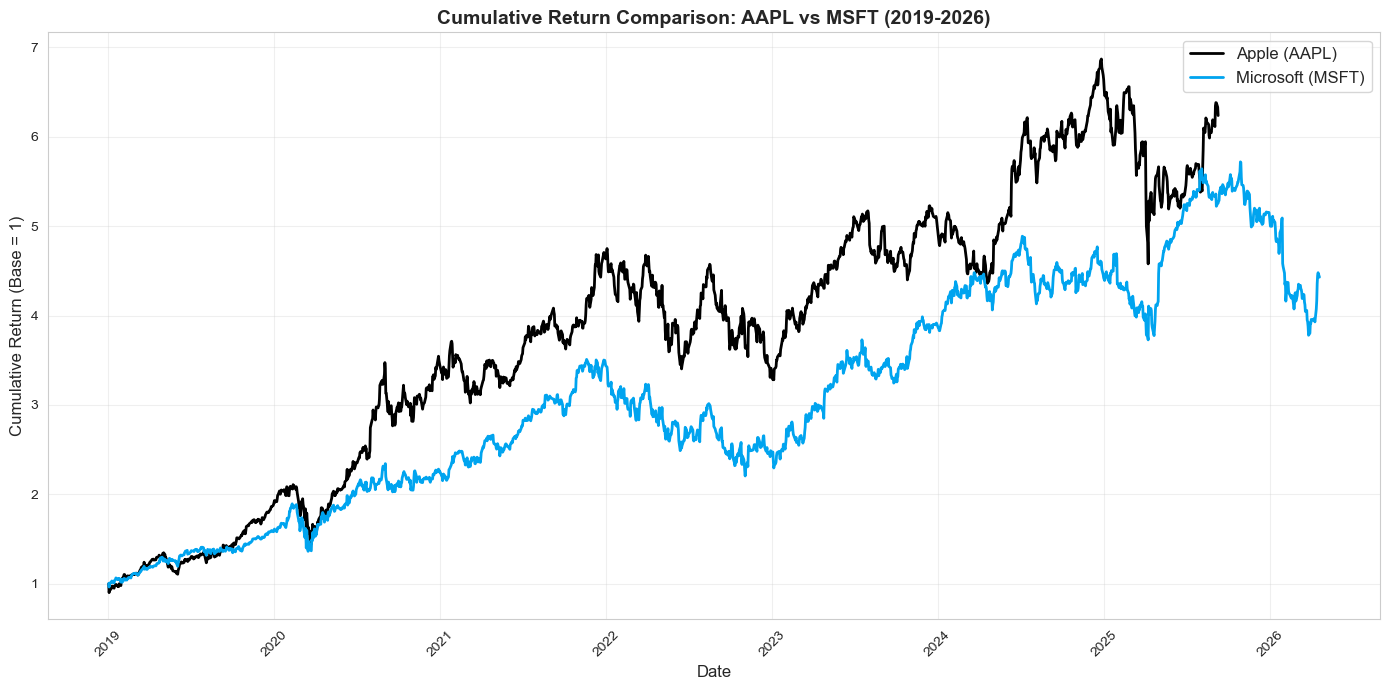

✅ Plot 2 saved: risk_return_comparison.png


<Figure size 1000x600 with 0 Axes>

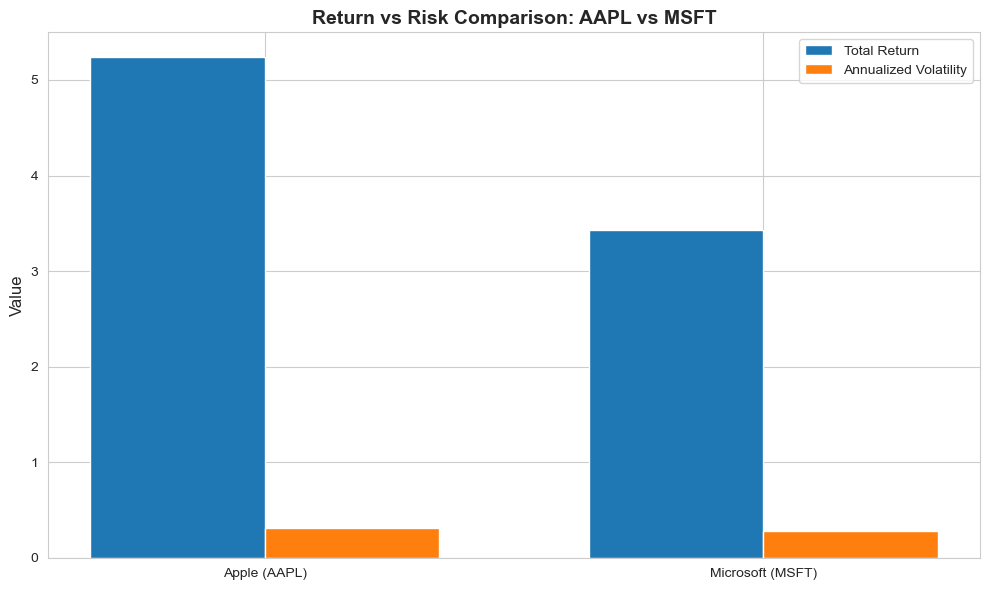

✅ Plot 3 saved: return_distribution.png


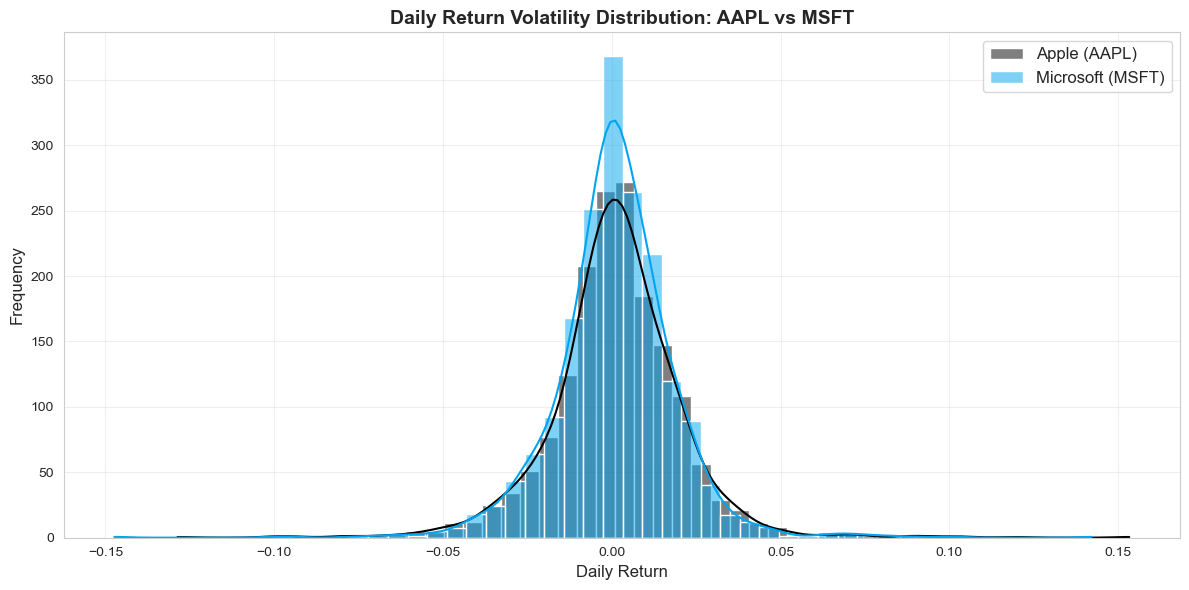


✅ Cleaned data saved as CSV files!

🎉 Analysis complete! You now have all required data and plots for your assignment.


In [5]:
# ==========================================
# ACC102 Track 2: AAPL vs MSFT Stock Analysis
# Fixed Version: Compatible with all column name formats
# ==========================================

# --------------------------
# Step 1: Import Required Libraries
# --------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# --------------------------
# Step 2: Load Your CSV Data & Check Columns
# --------------------------
print("Loading data...")

# Load CSV files
df_aapl = pd.read_csv("Apple_stock_data.csv")
df_msft = pd.read_csv("Microsoft_stock_data.csv")

# Auto-detect price column: Prioritize adjusted close, use close if not available
def get_price_column(df):
    # Compatible with all common column name variations
    possible_columns = ['Adj Close', 'AdjClose', 'Adjusted Close', 'adj close', 'Close', 'close']
    for col in possible_columns:
        if col in df.columns:
            return col
    # Raise clear error if no valid column found
    raise ValueError("No valid price column found in your CSV. Please check column names!")

aapl_price_col = get_price_column(df_aapl)
msft_price_col = get_price_column(df_msft)

print(f"✅ Apple data using price column: {aapl_price_col}")
print(f"✅ Microsoft data using price column: {msft_price_col}")
print("\n--- Apple Data Preview ---")
print(df_aapl.head())
print("\n--- Microsoft Data Preview ---")
print(df_msft.head())

# --------------------------
# Step 3: Data Cleaning & Preprocessing
# --------------------------
print("\nCleaning data...")

# 1. Convert 'Date' column to datetime format
df_aapl['Date'] = pd.to_datetime(df_aapl['Date'])
df_msft['Date'] = pd.to_datetime(df_msft['Date'])

# 2. Filter data to your target period: 2019-01-01 to 2026-04-21
start_date = '2019-01-01'
end_date = '2026-04-21'

df_aapl_clean = df_aapl[(df_aapl['Date'] >= start_date) & (df_aapl['Date'] <= end_date)].copy()
df_msft_clean = df_msft[(df_msft['Date'] >= start_date) & (df_msft['Date'] <= end_date)].copy()

# 3. Sort by date and drop missing values
df_aapl_clean = df_aapl_clean.sort_values('Date').reset_index(drop=True).dropna()
df_msft_clean = df_msft_clean.sort_values('Date').reset_index(drop=True).dropna()

print("✅ Data cleaned!")
print(f"Apple valid data rows (2019-2026): {len(df_aapl_clean)}")
print(f"Microsoft valid data rows (2019-2026): {len(df_msft_clean)}")

# --------------------------
# Step 4: Calculate Key Financial Indicators
# --------------------------
print("\nCalculating indicators...")

# --- 4.1 Daily Return (Calculated using auto-detected price column)
df_aapl_clean['Daily_Return'] = df_aapl_clean[aapl_price_col].pct_change()
df_msft_clean['Daily_Return'] = df_msft_clean[msft_price_col].pct_change()

# --- 4.2 Cumulative Return (Base: 2019-01-01 = 1)
df_aapl_clean['Cumulative_Return'] = (1 + df_aapl_clean['Daily_Return'].fillna(0)).cumprod()
df_msft_clean['Cumulative_Return'] = (1 + df_msft_clean['Daily_Return'].fillna(0)).cumprod()

# --- 4.3 Annualized Volatility (Risk measurement, 252 = annual trading days)
aapl_vol = df_aapl_clean['Daily_Return'].std() * np.sqrt(252)
msft_vol = df_msft_clean['Daily_Return'].std() * np.sqrt(252)

# --- 4.4 Total Return over the full period
aapl_total_return = df_aapl_clean['Cumulative_Return'].iloc[-1] - 1
msft_total_return = df_msft_clean['Cumulative_Return'].iloc[-1] - 1

# --- 4.5 Max Drawdown (Downside risk indicator, bonus point)
def calculate_max_drawdown(cumulative_return):
    peak = cumulative_return.cummax()
    drawdown = (cumulative_return - peak) / peak
    return drawdown.min()

aapl_max_drawdown = calculate_max_drawdown(df_aapl_clean['Cumulative_Return'])
msft_max_drawdown = calculate_max_drawdown(df_msft_clean['Cumulative_Return'])

print("✅ Indicators calculated!")
print("\n=== Key Analysis Results Summary ===")
print(f"Apple (AAPL) Total Return (2019-2026): {aapl_total_return:.2%}")
print(f"Microsoft (MSFT) Total Return (2019-2026): {msft_total_return:.2%}")
print(f"Apple (AAPL) Annualized Volatility: {aapl_vol:.4f}")
print(f"Microsoft (MSFT) Annualized Volatility: {msft_vol:.4f}")
print(f"Apple (AAPL) Max Drawdown: {aapl_max_drawdown:.2%}")
print(f"Microsoft (MSFT) Max Drawdown: {msft_max_drawdown:.2%}")

# --------------------------
# Step 5: Generate Visualizations (Auto-save images to folder)
# --------------------------
print("\nGenerating plots...")

# --- Plot 1: Cumulative Return Comparison (Core plot for assignment, must include in GitHub)
plt.figure(figsize=(14, 7))
plt.plot(df_aapl_clean['Date'], df_aapl_clean['Cumulative_Return'], label='Apple (AAPL)', color='#000000', linewidth=2)
plt.plot(df_msft_clean['Date'], df_msft_clean['Cumulative_Return'], label='Microsoft (MSFT)', color='#00A4EF', linewidth=2)
plt.title('Cumulative Return Comparison: AAPL vs MSFT (2019-2026)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return (Base = 1)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('cumulative_return_comparison.png', dpi=300) # Auto-save plot
print("✅ Plot 1 saved: cumulative_return_comparison.png")
plt.show()

# --- Plot 2: Return vs Risk Comparison Bar Chart
plt.figure(figsize=(10, 6))
companies = ['Apple (AAPL)', 'Microsoft (MSFT)']
total_returns = [aapl_total_return, msft_total_return]
volatilities = [aapl_vol, msft_vol]

x = np.arange(len(companies))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, total_returns, width, label='Total Return', color='#1f77b4')
rects2 = ax.bar(x + width/2, volatilities, width, label='Annualized Volatility', color='#ff7f0e')

ax.set_ylabel('Value', fontsize=12)
ax.set_title('Return vs Risk Comparison: AAPL vs MSFT', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(companies)
ax.legend()
plt.tight_layout()
plt.savefig('risk_return_comparison.png', dpi=300)
print("✅ Plot 2 saved: risk_return_comparison.png")
plt.show()

# --- Plot 3: Daily Return Volatility Distribution (Bonus point)
plt.figure(figsize=(12, 6))
sns.histplot(df_aapl_clean['Daily_Return'].dropna(), bins=50, label='Apple (AAPL)', color='#000000', alpha=0.5, kde=True)
sns.histplot(df_msft_clean['Daily_Return'].dropna(), bins=50, label='Microsoft (MSFT)', color='#00A4EF', alpha=0.5, kde=True)
plt.title('Daily Return Volatility Distribution: AAPL vs MSFT', fontsize=14, fontweight='bold')
plt.xlabel('Daily Return', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('return_distribution.png', dpi=300)
print("✅ Plot 3 saved: return_distribution.png")
plt.show()

# --------------------------
# Step 6: Save Cleaned Data (Optional, for GitHub upload)
# --------------------------
df_aapl_clean.to_csv("AAPL_cleaned_2019_2026.csv", index=False)
df_msft_clean.to_csv("MSFT_cleaned_2019_2026.csv", index=False)
print("\n✅ Cleaned data saved as CSV files!")
print("\n🎉 Analysis complete! You now have all required data and plots for your assignment.")